# CELL 1: CÀI ĐẶT THƯ VIỆN & IMPORT

In [1]:
# ==============================================================================
# CELL 1: CÀI ĐẶT THƯ VIỆN & IMPORT
# ==============================================================================
!pip -q install datasets huggingface_hub sentence-transformers neo4j sqlalchemy psycopg2-binary

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, DatasetDict
from huggingface_hub import login
from sentence_transformers import SentenceTransformer
from kaggle_secrets import UserSecretsClient
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 50.7 MB/s eta 0:00:00


In [2]:
# Khởi tạo token HuggingFace từ Kaggle Secrets
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)

In [3]:
PATHS = {
    "scientbank" : "nkazi/SciEntsBank",
    "mohler"     : "nkazi/MohlerASAG",
    "openstax"   : "/kaggle/input/datasets/nguynnghabi/unified-dataset/data_scraping.jsonl",
    "llm"        : "/kaggle/input/datasets/nguynnghabi/unified-dataset/data_generate.jsonl",
}

# CELL 2: LOAD DỮ LIỆU 

In [4]:
# ==============================================================================
# CELL 2: LOAD 4 DATASETS (TỪ HUGGINGFACE VÀ KAGGLE LOCAL)
# ==============================================================================
from datasets import load_dataset, get_dataset_config_names

# Định nghĩa đường dẫn và tên repository
PATHS = {
    "scientbank": "nkazi/SciEntsBank",
    "mohler": "nkazi/MohlerASAG",
    "openstax": "/kaggle/input/datasets/nguynnghabi/unified-dataset/data_scraping.jsonl",
    "llm": "/kaggle/input/datasets/nguynnghabi/unified-dataset/data_generate.jsonl"
}

# ── 1. SciEntsBank ───────────────────────────────────────────
print("⏳ Đang tải SciEntsBank...")
scib_ds = load_dataset(PATHS["scientbank"])
scib_list = []
for split_name, ds in scib_ds.items():
    tmp = ds.to_pandas().copy()
    tmp['split'] = split_name
    scib_list.append(tmp)
    
scib_raw = pd.concat(scib_list, ignore_index=True)
scib_raw = scib_raw.rename(columns={
    'id': 'sample_id', 
    'label': 'label_raw',
    'referenceanswer': 'reference_answer',
    'studentanswer': 'student_answer',
})
scib_raw['source'] = 'SciEntsBank'

# ── 2. Mohler ASAG ───────────────────────────────────────────
print("⏳ Đang tải Mohler ASAG...")
mohler_configs = get_dataset_config_names(PATHS["mohler"])
print("   -> Mohler configs:", mohler_configs)

mohler_frames = []
for cfg in mohler_configs:
    ds = load_dataset(PATHS["mohler"], name=cfg)
    for sp, d in ds.items():
        tmp = d.to_pandas().copy()
        tmp['split'] = sp
        tmp['config'] = cfg
        mohler_frames.append(tmp)
        
mohler_raw = pd.concat(mohler_frames, ignore_index=True)

# Chuẩn hóa tên cột cho Mohler (dataset dùng snake_case với underscore)
mohler_raw = mohler_raw.rename(columns={
    'instructor_answer': 'reference_answer',   
    'score_grader_1': 'score_grader1',          
    'score_grader_2': 'score_grader2',
})
mohler_raw['source'] = 'Mohler'

# ── 3. OpenStax (scraping) ───────────────────────────────────
print("⏳ Đang tải OpenStax...")
openstax_raw = pd.read_json(PATHS["openstax"], lines=True)
# Chuẩn hóa tên cột: xóa khoảng trắng, in thường, thay space bằng underscore
openstax_raw.columns = [c.strip().lower().replace(' ', '_') for c in openstax_raw.columns]
openstax_raw['source'] = 'OpenStax'

# ── 4. LLM Generated ────────────────────────────────────────
print("⏳ Đang tải LLM Generated...")
llm_raw = pd.read_json(PATHS["llm"], lines=True)
llm_raw.columns = [c.strip().lower().replace(' ', '_') for c in llm_raw.columns]
llm_raw['source'] = 'LLM_Generated'

# ── Kiểm tra kích thước dữ liệu ──────────────────────────────
print(f"\n📊 Shape của các bộ dữ liệu:")
print(f"  SciEntsBank : {scib_raw.shape}")
print(f"  Mohler      : {mohler_raw.shape}")
print(f"  OpenStax    : {openstax_raw.shape}")
print(f"  LLM         : {llm_raw.shape}")

⏳ Đang tải SciEntsBank...


README.md: 0.00B [00:00, ?B/s]

data/train-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

data/test-ua-00001.parquet:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

data/test-uq-00001.parquet:   0%|          | 0.00/35.7k [00:00<?, ?B/s]

...

Generating open_ended split:   0%|          | 0/2273 [00:00<?, ? examples/s]

Generating close_ended split:   0%|          | 0/169 [00:00<?, ? examples/s]

data/annotations-00001.parquet:   0%|          | 0.00/15.0k [00:00<?, ?B/s]

Generating annotations split:   0%|          | 0/32 [00:00<?, ? examples/s]

⏳ Đang tải OpenStax...
⏳ Đang tải LLM Generated...

📊 Shape của các bộ dữ liệu:
  SciEntsBank : (10804, 7)
  Mohler      : (7358, 11)
  OpenStax    : (129, 38)
  LLM         : (10000, 38)


# CELL 3: THUẬT TOÁN HỢP NHẤT DỮ LIỆU (DATA MERGING ALGORITHM)

In [5]:
# ==============================================================================
# CELL 3: THUẬT TOÁN HỢP NHẤT DỮ LIỆU (ĐÃ SỬA LỖI VALUEERROR FLOAT)
# ==============================================================================
import pandas as pd

def process_scientbank(df):
    df_clean = pd.DataFrame()
    df_clean['question'] = df['question']
    df_clean['reference_answer'] = df['reference_answer']
    df_clean['student_answer'] = df['student_answer']
    # Mapping label: 0 -> correct (1.0), 1,2 -> partially_correct (0.5), 3,4 -> incorrect (0.0)
    score_map = {0: 1.0, 1: 0.5, 2: 0.5, 3: 0.0, 4: 0.0}
    df_clean['score'] = df['label_raw'].map(score_map)
    df_clean['feedback'] = "" 
    df_clean['source'] = 'SciEntsBank'
    return df_clean

def process_mohler(df):
    df_clean = pd.DataFrame()
    df_clean['question'] = df['question']
    df_clean['reference_answer'] = df['reference_answer']
    df_clean['student_answer'] = df['student_answer']
    # Mohler score từ 0-5, chuẩn hóa về 0-1
    bins = [0, 2.5, 5]
    labels = [0.0, 0.5, 1.0]
    df_clean['score'] = pd.cut(df['score_avg'], bins=[-0.1,0.1,2.6,5.1], labels=labels)
    df_clean['feedback'] = ""
    df_clean['source'] = 'Mohler'
    return df_clean

def process_llm_openstax(df, source_name):
    df_clean = pd.DataFrame()
    
    COL_QUESTION = 'question'               
    COL_REF_ANSWER = 'reference_answer'     
    COL_STUDENT_ANSWER = 'student_answer'   
    COL_SCORE = 'score_raw'                     
    COL_FEEDBACK = 'feedback_detailed'                    
    
    try:
        df_clean['question'] = df[COL_QUESTION]
        df_clean['reference_answer'] = df[COL_REF_ANSWER]
        df_clean['student_answer'] = df[COL_STUDENT_ANSWER]

        bins = [0, 2.5, 5]
        labels = [0.0, 0.5, 1.0]
        df_clean['score'] = pd.cut(df[COL_SCORE], bins=[-0.1,0.1,2.6,5.1], labels=labels)
        
        if COL_FEEDBACK in df.columns:
            df_clean['feedback'] = df[COL_FEEDBACK]
        else:
            df_clean['feedback'] = ""
            
        df_clean['source'] = source_name
        return df_clean
        
    except KeyError as e:
        print(f"\n❌ LỖI: Không tìm thấy cột {e} trong bộ dữ liệu {source_name}!")
        print(f"👉 Danh sách cột hiện có trong {source_name} là:\n{df.columns.tolist()}")
        raise e

# Tiến hành hợp nhất
try:
    df_merged = pd.concat([
        process_scientbank(scib_raw),
        process_mohler(mohler_raw),
        process_llm_openstax(openstax_raw, 'OpenStax'),
        process_llm_openstax(llm_raw, 'LLM_Generated')
    ], ignore_index=True)

    # ⚠️ BƯỚC SỬA LỖI: Drop NaNs và reset index TRƯỚC khi tạo ID
    df_merged.dropna(subset=['question', 'reference_answer', 'student_answer', 'score'], inplace=True)
    df_merged.reset_index(drop=True, inplace=True)

    # Tạo ID định danh duy nhất cho CSDL
    df_merged['response_id'] = [f"R_{i:06d}" for i in range(len(df_merged))]
    
    # Ép kiểu astype(int) trước khi format chuỗi để đảm bảo an toàn tuyệt đối
    df_merged['question_id'] = df_merged.groupby('question').ngroup().astype(int).apply(lambda x: f"Q_{x:04d}")

    print(f"\n✅ Hợp nhất thành công! Tổng số mẫu sau hợp nhất: {len(df_merged)}")
    
except KeyError:
    pass


✅ Hợp nhất thành công! Tổng số mẫu sau hợp nhất: 28130


In [6]:
df_merged['score'].value_counts()

score
1.0    15914
0.5     8585
0.0     3631
Name: count, dtype: int64

# CELL 4: TRỰC QUAN HÓA VÀ EDA DỮ LIỆU ĐÃ HỢP NHẤT (POST-MERGE EDA)

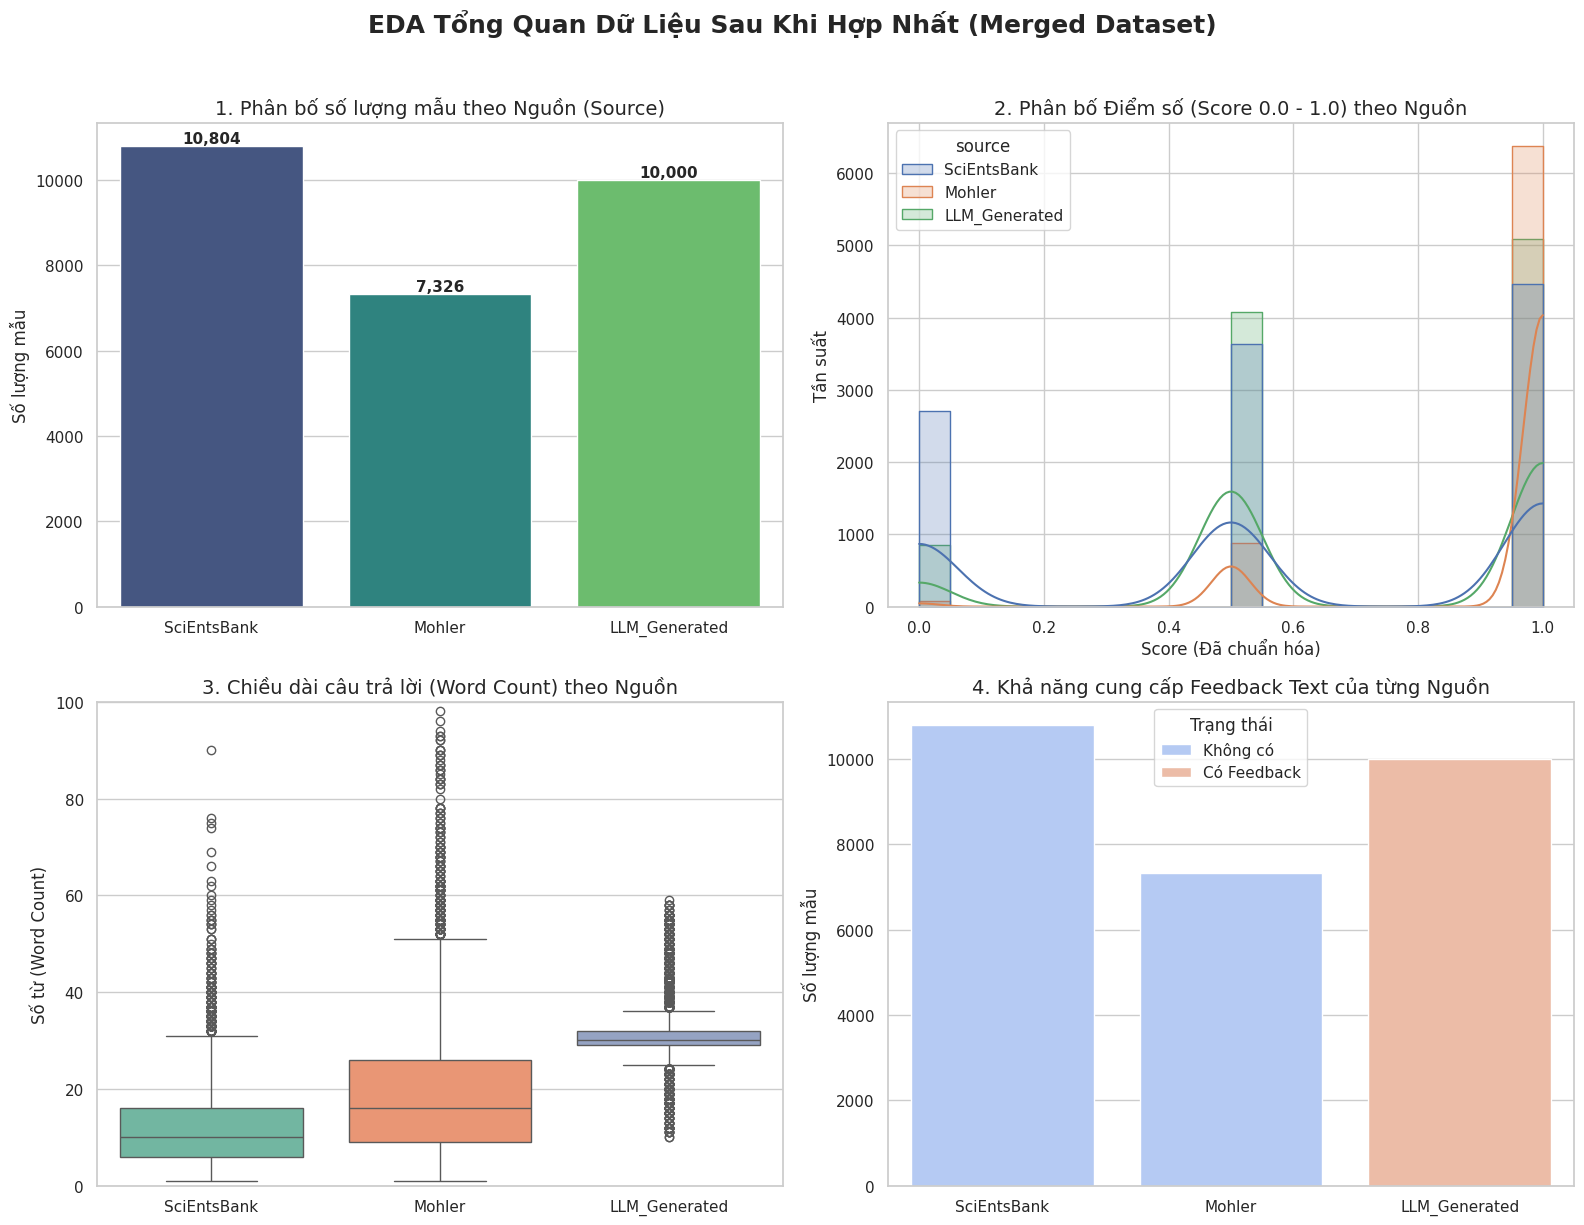

📊 BẢNG THỐNG KÊ CHI TIẾT DỮ LIỆU ĐÃ HỢP NHẤT


,Tổng_Mẫu,Điểm_TB,Điểm_ĐộLệchChuẩn,SốTừ_TB_HọcSinh,Số_Mẫu_Có_Feedback
source,,,,,
LLM_Generated,10000,0.712000,0.322000,31.140000,10000
Mohler,7326,0.930000,0.187000,19.540000,0
SciEntsBank,10804,0.581000,0.399000,12.030000,0
TỔNG CỘNG / TRUNG BÌNH,28130,0.718326,0.355022,20.779524,10000


In [7]:
# ==============================================================================
# CELL 4: TRỰC QUAN HÓA VÀ EDA DỮ LIỆU ĐÃ HỢP NHẤT (POST-MERGE EDA)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Thiết lập phong cách đồ thị
sns.set_theme(style="whitegrid")

# Thêm cột Word Count cho câu trả lời của học sinh để phân tích
df_merged['student_answer_wc'] = df_merged['student_answer'].astype(str).apply(lambda x: len(x.split()))
# Thêm cột cờ (flag) kiểm tra xem mẫu có feedback hay không
df_merged['has_feedback'] = df_merged['feedback'].apply(lambda x: 'Có Feedback' if len(str(x).strip()) > 0 else 'Không có')

# Tạo figure lớn với lưới 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('EDA Tổng Quan Dữ Liệu Sau Khi Hợp Nhất (Merged Dataset)', fontsize=18, fontweight='bold', y=1.02)

# --- Biểu đồ 1: Phân bố số lượng mẫu theo Nguồn (Source) ---
sns.countplot(data=df_merged, x='source', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('1. Phân bố số lượng mẫu theo Nguồn (Source)', fontsize=14)
axes[0, 0].set_ylabel('Số lượng mẫu', fontsize=12)
axes[0, 0].set_xlabel('')
# Thêm annotation số lượng trực tiếp lên cột
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height()):,}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Biểu đồ 2: Phân bố Điểm số (Score Distribution) theo Nguồn ---
# Sử dụng KDE plot kết hợp histogram để thấy rõ sự phân cực điểm số
sns.histplot(data=df_merged, x='score', bins=20, kde=True, hue='source', element="step", ax=axes[0, 1])
axes[0, 1].set_title('2. Phân bố Điểm số (Score 0.0 - 1.0) theo Nguồn', fontsize=14)
axes[0, 1].set_xlabel('Score (Đã chuẩn hóa)', fontsize=12)
axes[0, 1].set_ylabel('Tần suất', fontsize=12)

# --- Biểu đồ 3: Phân tích chiều dài câu trả lời (Word Count) ---
# Boxplot giúp phát hiện các outlier (câu trả lời quá dài)
sns.boxplot(data=df_merged, x='source', y='student_answer_wc', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('3. Chiều dài câu trả lời (Word Count) theo Nguồn', fontsize=14)
axes[1, 0].set_ylabel('Số từ (Word Count)', fontsize=12)
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylim(0, 100) # Giới hạn hiển thị 100 từ để biểu đồ rõ ràng hơn, ẩn bớt extreme outliers

# --- Biểu đồ 4: Tỉ lệ khả dụng của Feedback Text ---
sns.countplot(data=df_merged, x='source', hue='has_feedback', palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('4. Khả năng cung cấp Feedback Text của từng Nguồn', fontsize=14)
axes[1, 1].set_ylabel('Số lượng mẫu', fontsize=12)
axes[1, 1].set_xlabel('')
axes[1, 1].legend(title='Trạng thái')

plt.tight_layout()
plt.savefig("/kaggle/working/EDA_merged_dataset.png")
plt.show()


# --- Thống kê mô tả dạng Text ---
print("=" * 70)
print("📊 BẢNG THỐNG KÊ CHI TIẾT DỮ LIỆU ĐÃ HỢP NHẤT")
print("=" * 70)
summary_df = df_merged.groupby('source').agg(
    Tổng_Mẫu=('response_id', 'count'),
    Điểm_TB=('score', 'mean'),
    Điểm_ĐộLệchChuẩn=('score', 'std'),
    SốTừ_TB_HọcSinh=('student_answer_wc', 'mean'),
    Số_Mẫu_Có_Feedback=('has_feedback', lambda x: (x == 'Có Feedback').sum())
).round(3)

# Tính tổng cộng cho toàn bộ dataset
summary_df.loc['TỔNG CỘNG / TRUNG BÌNH'] = [
    summary_df['Tổng_Mẫu'].sum(),
    df_merged['score'].mean(),
    df_merged['score'].std(),
    df_merged['student_answer_wc'].mean(),
    summary_df['Số_Mẫu_Có_Feedback'].sum()
]

# Chuyển đổi định dạng cho dễ nhìn
summary_df['Tổng_Mẫu'] = summary_df['Tổng_Mẫu'].astype(int)
summary_df['Số_Mẫu_Có_Feedback'] = summary_df['Số_Mẫu_Có_Feedback'].astype(int)

display(summary_df)

# Xóa các cột tạm để không đưa vào HuggingFace Dataset
df_merged.drop(columns=['student_answer_wc', 'has_feedback'], inplace=True)

# CELL 5: TRÍCH XUẤT NHÚNG (EMBEDDING) CHO NEO4J & RETRIEVAL

In [8]:
# ==============================================================================
# CELL 5: TRÍCH XUẤT NHÚNG (EMBEDDING) CHO NEO4J & RETRIEVAL
# Sử dụng SentenceTransformer (nhẹ, chạy nhanh trên Kaggle T4 GPU)
# ==============================================================================
print("Khởi tạo mô hình Embedding...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Nhúng câu trả lời của học sinh (sẽ hữu ích cho Neo4j để tìm các câu trả lời tương đồng)
print("Đang trích xuất embeddings...")
student_embeddings = embedder.encode(df_merged['student_answer'].tolist(), show_progress_bar=True)

# Chuyển embedding thành list để lưu trữ vào HuggingFace Dataset
df_merged['student_answer_embedding'] = student_embeddings.tolist()

Khởi tạo mô hình Embedding...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Đang trích xuất embeddings...


Batches:   0%|          | 0/880 [00:00<?, ?it/s]

# CELL 6: ĐẨY DỮ LIỆU LÊN HUGGINGFACE HUB

In [9]:
# ==============================================================================
# CELL 6: ĐẨY DỮ LIỆU LÊN HUGGINGFACE HUB
# ==============================================================================
# Phân chia Train/Test/Val dựa trên question_id để tránh Data Leakage
unique_q_ids = df_merged['question_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_q_ids)

train_split = int(0.8 * len(unique_q_ids))
val_split = int(0.9 * len(unique_q_ids))

train_q_ids = unique_q_ids[:train_split]
val_q_ids = unique_q_ids[train_split:val_split]
test_q_ids = unique_q_ids[val_split:]

train_df = df_merged[df_merged['question_id'].isin(train_q_ids)]
val_df = df_merged[df_merged['question_id'].isin(val_q_ids)]
test_df = df_merged[df_merged['question_id'].isin(test_q_ids)]

# Tạo DatasetDict
hf_dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df.drop(columns=['__index_level_0__'], errors='ignore')),
    'validation': Dataset.from_pandas(val_df.drop(columns=['__index_level_0__'], errors='ignore')),
    'test': Dataset.from_pandas(test_df.drop(columns=['__index_level_0__'], errors='ignore'))
})

REPO_ID = "nguyennghia0902/unified-feedback-grading-adb"
hf_dataset.push_to_hub(REPO_ID)
print(f"✅ Dữ liệu đã được đẩy thành công lên: https://huggingface.co/datasets/{REPO_ID}")


Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Dữ liệu đã được đẩy thành công lên: https://huggingface.co/datasets/nguyennghia0902/unified-feedback-grading-adb


# CELL 7: KHỞI TẠO CƠ SỞ DỮ LIỆU QUAN HỆ (POSTGRESQL & NEO4J MOCKUP)

## ==============================================================================
# CELL 7: KHỞI TẠO CƠ SỞ DỮ LIỆU QUAN HỆ & ĐỒ THỊ (MINH HỌA)
# ==============================================================================
from sqlalchemy import create_engine, text
from neo4j import GraphDatabase

print("="*60)
print("🗄️ KHỞI TẠO MINH HỌA POSTGRESQL (RELATIONAL DB)")
print("="*60)

# 1. CẤU HÌNH POSTGRESQL (Chạy trên Docker Local)
# Hãy thay đổi User, Password, DB_Name cho khớp với cấu hình Docker/DBeaver của bạn
PG_USER = "postgres"
PG_PASS = "your_password"
PG_HOST = "localhost"
PG_PORT = "5432"
PG_DB   = "feedback_db"

pg_uri = f"postgresql://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}"

try:
    engine = create_engine(pg_uri)
    with engine.connect() as conn:
        # Xóa bảng cũ nếu tồn tại (để test nhiều lần)
        conn.execute(text("DROP TABLE IF EXISTS Evaluations CASCADE;"))
        conn.execute(text("DROP TABLE IF EXISTS Student_Responses CASCADE;"))
        conn.execute(text("DROP TABLE IF EXISTS Questions CASCADE;"))
        
        # Tạo bảng Questions
        conn.execute(text("""
            CREATE TABLE Questions (
                question_id VARCHAR(50) PRIMARY KEY,
                question_text TEXT NOT NULL,
                reference_answer TEXT NOT NULL,
                source VARCHAR(50)
            );
        """))
        
        # Tạo bảng Student_Responses
        conn.execute(text("""
            CREATE TABLE Student_Responses (
                response_id VARCHAR(50) PRIMARY KEY,
                question_id VARCHAR(50),
                student_answer_text TEXT NOT NULL,
                FOREIGN KEY(question_id) REFERENCES Questions(question_id)
            );
        """))
        
        # Tạo bảng Evaluations
        conn.execute(text("""
            CREATE TABLE Evaluations (
                evaluation_id SERIAL PRIMARY KEY,
                response_id VARCHAR(50),
                score FLOAT,
                feedback_text TEXT,
                FOREIGN KEY(response_id) REFERENCES Student_Responses(response_id)
            );
        """))
        conn.commit()
        print("✅ Đã tạo thành công schema 3 bảng: Questions, Student_Responses, Evaluations trên PostgreSQL.")
        
        # Thêm 1 dòng dữ liệu minh họa
        conn.execute(text("""
            INSERT INTO Questions (question_id, question_text, reference_answer, source)
            VALUES ('Q_0001', 'What is OOP?', 'Object-Oriented Programming', 'SciEntsBank');
        """))
        conn.commit()
        print("✅ Đã chèn dữ liệu mẫu vào PostgreSQL. Có thể mở DBeaver để kiểm tra!")
        
except Exception as e:
    print("❌ Lỗi kết nối PostgreSQL:", e)


print("\n" + "="*60)
print("🕸️ KHỞI TẠO MINH HỌA NEO4J (GRAPH DB)")
print("="*60)

# 2. CẤU HÌNH NEO4J (Chạy trên Docker Local)
NEO4J_URI = "bolt://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_PASS = "your_password"

try:
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))
    
    def setup_graph_schema(tx):
        # Tạo Constraints (Chỉ mục duy nhất)
        tx.run("CREATE CONSTRAINT question_id IF NOT EXISTS FOR (q:Question) REQUIRE q.id IS UNIQUE")
        tx.run("CREATE CONSTRAINT response_id IF NOT EXISTS FOR (r:Response) REQUIRE r.id IS UNIQUE")
        
        # Xóa dữ liệu mẫu cũ (nếu có)
        tx.run("MATCH (n) DETACH DELETE n")
        
        # Chèn dữ liệu đồ thị minh họa (Nodes & Relationships)
        query = """
        MERGE (q:Question {id: 'Q_0001', text: 'What is OOP?', source: 'SciEntsBank'})
        MERGE (r:Response {id: 'R_000001', text: 'It is Object Oriented Programming', score: 1.0})
        MERGE (e:Evaluation {id: 'E_0001', feedback: 'Correct and concise.'})
        
        // Tạo mối quan hệ
        MERGE (r)-[:ANSWERS]->(q)
        MERGE (e)-[:EVALUATES]->(r)
        """
        tx.run(query)
    
    with driver.session() as session:
        session.execute_write(setup_graph_schema)
        print("✅ Đã tạo thành công Graph Schema và Constraints trên Neo4j.")
        print("✅ Đã chèn Node và Relationship mẫu. Bạn có thể mở http://localhost:7474 để xem biểu đồ!")
        
    driver.close()
    
except Exception as e:
    print("❌ Lỗi kết nối Neo4j:", e)